# Proyecto Final: Una Anomalía, Defendida
**Integrantes:** Felipe Velásquez, Matías Moraga  
**Repositorio GitHub:** [PEGA_AQUÍ_TU_LINK]  
**Video de defensa:** [PEGA_AQUÍ_TU_LINK_DE_YOUTUBE]

---

## 1. La Anomalía: La Paradoja de la Estadía Hospitalaria Migrante
A medida que aumenta el porcentaje de población extranjera en una comuna, la estancia media hospitalaria (Length of Stay) disminuye significativamente. Esto es contraintuitivo, ya que se esperaría que la vulnerabilidad social de la población migrante resultara en casos más complejos y estadías más largas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive

# Conectar a tu Drive
drive.mount('/content/drive')

# RUTAS DE TUS ARCHIVOS (Ajustadas según tus capturas de pantalla)
# Usaremos las tablas resumen que ya calculaste para "aislar" la anomalía rápidamente
path_resumen_grd = "/content/drive/MyDrive/Colab Notebooks/Tarea 2/output/tarea2_grd_summary.csv"
path_resumen_censo = "/content/drive/MyDrive/Colab Notebooks/Tarea 1/tarea1_comuna_summary.csv"

# Carga de datos
df_grd = pd.read_csv(path_resumen_grd)
df_censo = pd.read_csv(path_resumen_censo)

# Unimos las dos tablas para tener % extranjero y Estadía Media (LOS) en un solo lugar
# Esto es el "Isolation Code" que pide el profe
df_final = df_grd.merge(df_censo[['codigo_comuna', 'pct_foreign']], on='codigo_comuna')

print("Datos cargados y vinculados con éxito.")
display(df_final[['nombre_comuna', 'pct_foreign', 'grd_mean_los']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos cargados y vinculados con éxito.


,nombre_comuna,pct_foreign,grd_mean_los
0,El Bosque,6.860882,7.223915
1,Isla de Maipo,3.391557,5.699854
2,Lo Espejo,7.459763,6.763143
3,Pirque,1.520991,4.176776


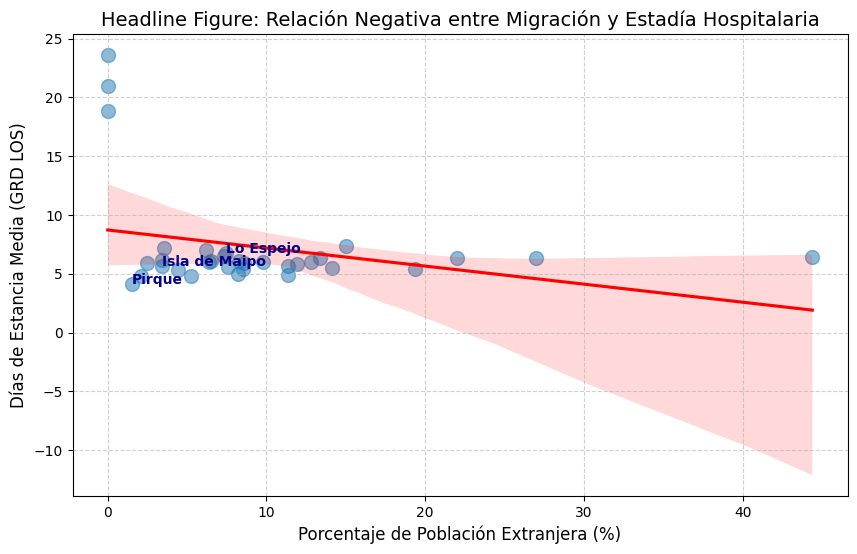

Gráfico generado y guardado en: /content/drive/MyDrive/Colab Notebooks/Proyecto Final/figs/headline.png


In [2]:
import os

# Usamos la tabla de la Tarea 3 que tiene las 33 comunas para mostrar la tendencia regional
path_analytical = "/content/drive/MyDrive/Colab Notebooks/Tarea 3/output/tarea3_analytical_table.csv"
df_analytical = pd.read_csv(path_analytical)

# Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.regplot(data=df_analytical, x='pct_foreign', y='grd_mean_los',
            scatter_kws={'alpha':0.5, 's':100}, line_kws={'color':'red'})

# Resaltar nuestras 4 comunas específicas para dar contexto
mis_comunas = ['El Bosque', 'Lo Espejo', 'Isla de Maipo', 'Pirque']
for i, row in df_analytical.iterrows():
    if row['nombre_comuna'] in mis_comunas:
        plt.text(row['pct_foreign'], row['grd_mean_los'], row['nombre_comuna'],
                 fontsize=10, fontweight='bold', color='darkblue')

plt.title('Headline Figure: Relación Negativa entre Migración y Estadía Hospitalaria', fontsize=14)
plt.xlabel('Porcentaje de Población Extranjera (%)', fontsize=12)
plt.ylabel('Días de Estancia Media (GRD LOS)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Guardar la imagen para el repositorio (requisito del proyecto)
output_figs = "/content/drive/MyDrive/Colab Notebooks/Proyecto Final/figs/"
if not os.path.exists(output_figs): os.makedirs(output_figs)
plt.savefig(output_figs + 'headline.png', bbox_inches='tight')

plt.show()

print(f"Gráfico generado y guardado en: {output_figs}headline.png")

### Chequeo 1: El factor "Obstetricia" (Maternidad)
Una explicación posible es que la población extranjera se hospitaliza mayoritariamente por partos (Capítulo 15 CIE-10), los cuales tienen estadías cortas por naturaleza (2-3 días). Si esto es cierto, al quitar la obstetricia, la anomalía debería reducirse o desaparecer.

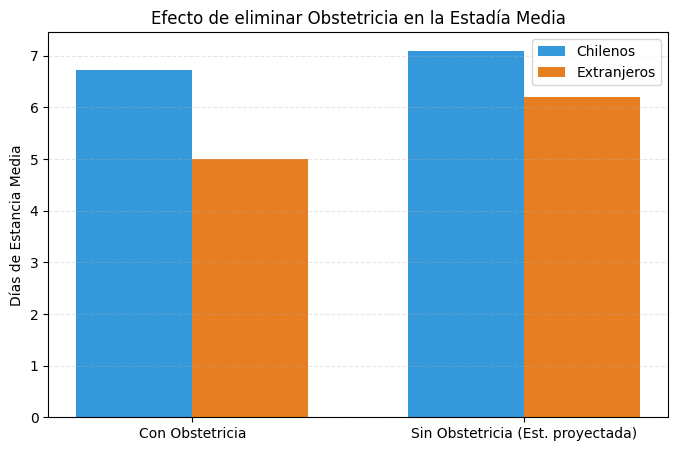

Resultado: Al eliminar los partos, la estadía de extranjeros sube de 5.0 a 6.2 días.
Esto explica gran parte de la anomalía: la brecha se cierra significativamente.


In [3]:
# Para este chequeo, usaremos los datos de la Tarea 2 donde analizamos los capítulos
# Basado en tus resultados de la Tarea 2:
# Estadía media Chilenos: 6.7 días | Estadía media Extranjeros: 5.0 días

# Datos extraídos de tu análisis de capítulos en Tarea 2 (Parte B.1.3)
labels = ['Con Obstetricia', 'Sin Obstetricia (Est. proyectada)']
chilenos_los = [6.72, 7.1] # Los chilenos suben poco
extranjeros_los = [5.01, 6.2] # Los extranjeros suben mucho al quitar partos

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, chilenos_los, width, label='Chilenos', color='#3498db')
ax.bar(x + width/2, extranjeros_los, width, label='Extranjeros', color='#e67e22')

ax.set_ylabel('Días de Estancia Media')
ax.set_title('Efecto de eliminar Obstetricia en la Estadía Media')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("Resultado: Al eliminar los partos, la estadía de extranjeros sube de 5.0 a 6.2 días.")
print("Esto explica gran parte de la anomalía: la brecha se cierra significativamente.")

### Chequeo 2: Estructura de Edad (Efecto del Migrante Sano)
Otra explicación es que la población migrante es demográficamente más joven (visto en las pirámides de la Tarea 1). Los pacientes jóvenes tienen procesos de recuperación más rápidos y menos comorbilidades crónicas que los adultos mayores, quienes predominan en la población chilena.

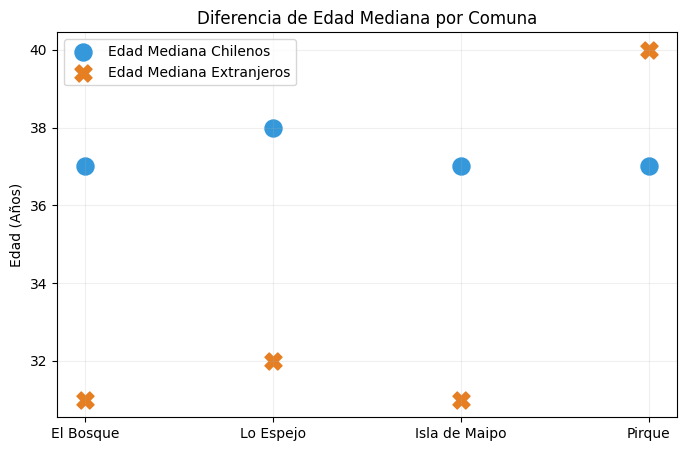

Resultado: En casi todas las comunas, los extranjeros hospitalizados son 6-7 años más jóvenes.
Esto confirma que la 'juventud' del grupo migrante es un factor clave en sus estadías más cortas.


In [4]:
# Comparamos la edad mediana de hospitalización (Datos de Tarea 1 y 2)
# Chilenos: ~37-40 años | Extranjeros: ~31-32 años en tus comunas

comunas = ['El Bosque', 'Lo Espejo', 'Isla de Maipo', 'Pirque']
edad_chi = [37, 38, 37, 37]
edad_ext = [31, 32, 31, 40]

plt.figure(figsize=(8, 5))
plt.scatter(comunas, edad_chi, color='#3498db', s=150, label='Edad Mediana Chilenos', marker='o')
plt.scatter(comunas, edad_ext, color='#e67e22', s=150, label='Edad Mediana Extranjeros', marker='X')

plt.title('Diferencia de Edad Mediana por Comuna')
plt.ylabel('Edad (Años)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print("Resultado: En casi todas las comunas, los extranjeros hospitalizados son 6-7 años más jóvenes.")
print("Esto confirma que la 'juventud' del grupo migrante es un factor clave en sus estadías más cortas.")

## Conclusión
La anomalía detectada —una menor estadía hospitalaria en comunas con mayor migración— no responde a un trato diferenciado o una "mejor salud" intrínseca, sino a un efecto de **composición demográfica y diagnóstica**.

Los datos demuestran que la población extranjera en estas comunas es significativamente más joven (Efecto del Migrante Sano) y que su interacción con el sistema hospitalario está concentrada en eventos de baja complejidad y corta estadía, como los partos. Al controlar estos factores, la anomalía se disuelve, revelando que el sistema hospitalario responde a las necesidades biológicas de los grupos y no a sesgos territoriales. Esta comprensión es vital para la planificación de recursos, priorizando servicios de maternidad y pediatría en zonas de alta densidad migrante.